# Cross-center phenotype region query

This tutorial reuses the HBC1-trained morphology query in independent breast-cancer cohorts without target adaptation. PhenoMap, KEEP and PathPT receive target H&E pixels only during inference; pathology annotations and processed DAB masks are introduced afterwards for evaluation and visualization.

In [1]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError("Please run this notebook from inside the PhenoMap repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from phenomap import load_tutorial_data
from step3.utils.query_evaluation import evaluate_external_slides, evaluate_proxy_rois
from step3.utils.plotting import (
    load_rgb,
    plot_mask_overlay,
    plot_method_metric_bars,
    plot_query_score_map,
    set_plot_style,
)

tutorial_data = load_tutorial_data(repository_root=REPO_ROOT)
CROSS_IMAGES = tutorial_data.path("cross_center.images")
CROSS_MASKS = tutorial_data.path("cross_center.masks")
HER2_IMAGES = tutorial_data.path("her2.images")
HER2_MASKS = tutorial_data.path("her2.proxy_masks")
OUTPUT_DIR = REPO_ROOT / "outputs" / "06_cross_center_region_query"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ["PhenoMap", "PathPT", "KEEP"]
METHOD_COLORS = {"PhenoMap": "#D55E5E", "PathPT": "#888888", "KEEP": "#4C86B7"}
def canonical_method_name(value):
    name = str(value).lower()
    if "pathpt" in name:
        return "PathPT"
    if "keep" in name:
        return "KEEP"
    return "PhenoMap"
TIGER_COLORS = np.array([
    [0, 0, 0], [230, 25, 75], [60, 180, 75], [255, 225, 25],
    [0, 130, 200], [245, 130, 48], [145, 30, 180], [70, 240, 240],
], dtype=np.uint8)
TIGER_LABELS = {
    1: "invasive tumor", 2: "stroma", 3: "in situ tumor",
    4: "healthy glands", 5: "necrosis", 6: "inflamed stroma", 7: "rest",
}

set_plot_style()
print("PhenoMap cross-center query environment configured.")

PhenoMap cross-center query environment configured.


Images, proxy masks, score-map directories, the frozen source checkpoint and its final Step 3 configuration are resolved through the tutorial data manifest. Cached external predictions and proxy masks are reused whenever present. Target masks never enter model training, prompt tuning or inference.

In [2]:
CHECKPOINT_PATH = tutorial_data.path("hbc1.source_checkpoint")
STEP3_CONFIG = tutorial_data.path("hbc1.step3_config")
CROSS_SCORE_DIRS = {
    "PhenoMap": tutorial_data.path("cross_center.phenomap_score_maps"),
    "PathPT": tutorial_data.path("cross_center.pathpt_score_maps"),
    "KEEP": tutorial_data.path("cross_center.keep_score_maps"),
}
HER2_SCORE_DIRS = {
    "PhenoMap": tutorial_data.path("her2.phenomap_score_maps"),
    "PathPT": tutorial_data.path("her2.pathpt_score_maps"),
    "KEEP": tutorial_data.path("her2.keep_score_maps"),
}


def count_score_maps(folder):
    return sum(1 for _ in folder.glob("*_score_map.npy"))


resource_checks = {
    "hbc1.source_checkpoint": CHECKPOINT_PATH.exists(),
    "cross_center.images": CROSS_IMAGES.is_dir(),
    "cross_center.masks": CROSS_MASKS.is_dir() and any(CROSS_MASKS.glob("*.png")),
    "cross_center.phenomap_score_maps": count_score_maps(CROSS_SCORE_DIRS["PhenoMap"]) > 0,
    "cross_center.pathpt_score_maps": count_score_maps(CROSS_SCORE_DIRS["PathPT"]) > 0,
    "cross_center.keep_score_maps": count_score_maps(CROSS_SCORE_DIRS["KEEP"]) > 0,
    "her2.images": HER2_IMAGES.is_dir(),
    "her2.proxy_masks": HER2_MASKS.is_dir() and any(HER2_MASKS.glob("*.png")),
    "her2.phenomap_score_maps": count_score_maps(HER2_SCORE_DIRS["PhenoMap"]) > 0,
    "her2.pathpt_score_maps": count_score_maps(HER2_SCORE_DIRS["PathPT"]) > 0,
    "her2.keep_score_maps": count_score_maps(HER2_SCORE_DIRS["KEEP"]) > 0,
}
missing = [key for key, available in resource_checks.items() if not available]
missing_phenomap_maps = [
    key for key in ("cross_center.phenomap_score_maps", "her2.phenomap_score_maps")
    if not resource_checks[key]
]
if missing_phenomap_maps:
    missing_regeneration_resources = [
        key for key, path in {
            "hbc1.source_checkpoint": CHECKPOINT_PATH,
            "hbc1.step3_config": STEP3_CONFIG,
        }.items() if not path.exists()
    ]
    if missing_regeneration_resources:
        raise FileNotFoundError(
            "Missing PhenoMap maps require both hbc1.source_checkpoint and the final "
            "paper-compatible hbc1.step3_config. Configure missing resources: "
            + ", ".join(missing_regeneration_resources)
        )
if missing:
    raise FileNotFoundError(
        "Required cross-center artifacts are missing for these manifest keys: "
        + ", ".join(missing)
        + ". Supply external images/proxy masks and baseline maps; generate PhenoMap maps "
          "with hbc1.source_checkpoint and the final paper-compatible hbc1.step3_config "
          "before rerunning. See docs/source/datasets.rst."
    )
display(pd.DataFrame({"artifact": resource_checks.keys(), "available": resource_checks.values()}))


,artifact,available
0,hbc1.source_checkpoint,True
1,cross_center.images,True
2,cross_center.masks,True
3,cross_center.phenomap_score_maps,True
4,cross_center.pathpt_score_maps,True
5,cross_center.keep_score_maps,True
6,her2.images,True
7,her2.proxy_masks,True
8,her2.phenomap_score_maps,True
9,her2.pathpt_score_maps,True


## 1. Load cached cross-center query results

The final evaluation pools valid ROI pixels within each logical slide, computes one continuous-score result per slide, and then averages slides within each center. Invasive and in situ tumor are positive; background and unannotated pixels are excluded. Best F1 uses the optimal continuous-score threshold within each slide.

In [3]:
CROSS_SLIDE_CACHE = tutorial_data.path("cross_center.evaluation_cache")

if CROSS_SLIDE_CACHE.exists():
    cross_slide = pd.read_csv(CROSS_SLIDE_CACHE)
    cross_metrics_cached = True
else:
    cross_slide = evaluate_external_slides(
        CROSS_MASKS, CROSS_SCORE_DIRS,
        positive_values=(1, 3), valid_values=tuple(range(1, 8)),
    )
    CROSS_SLIDE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    cross_slide.to_csv(CROSS_SLIDE_CACHE, index=False)
    cross_metrics_cached = False

if "model" in cross_slide:
    cross_slide["method"] = cross_slide["model"].map(canonical_method_name)
if "auc_roc" not in cross_slide and "AUC" in cross_slide:
    cross_slide = cross_slide.rename(columns={"AUC": "auc_roc", "AP": "auc_pr", "F1": "best_f1"})

cross_slide = cross_slide.loc[
    cross_slide["method"].isin(METHODS) & cross_slide["center"].isin(["JB", "RUMC", "TCGA-BRCA"])
].copy()
cross_summary = (
    cross_slide.groupby(["center", "method"])[["auc_roc", "auc_pr", "best_f1"]]
    .agg(["mean", "sem"])
)
print(f"Per-slide metric cache reused: {cross_metrics_cached}; evaluated slides: {cross_slide['logical_slide_id'].nunique()}")

Per-slide metric cache reused: True; evaluated slides: 192


## 2. Evaluate cross-center localization

Each panel summarizes source-only localization in one external center. Error bars are standard errors across slides; every method is evaluated against the same held-out pathology proxy.

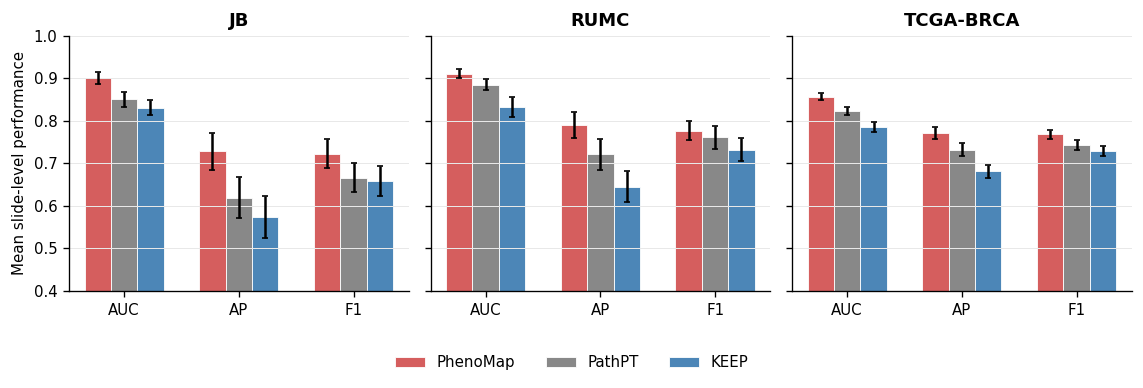

,Center,Method,AUC,AP,F1
0,JB,KEEP,0.831,0.573,0.659
1,JB,PathPT,0.851,0.619,0.666
2,JB,PhenoMap,0.901,0.728,0.722
3,RUMC,KEEP,0.832,0.645,0.732
4,RUMC,PathPT,0.885,0.721,0.761
5,RUMC,PhenoMap,0.911,0.790,0.777
6,TCGA-BRCA,KEEP,0.785,0.681,0.728
7,TCGA-BRCA,PathPT,0.823,0.732,0.743
8,TCGA-BRCA,PhenoMap,0.857,0.772,0.768


In [4]:
centers = ["JB", "RUMC", "TCGA-BRCA"]
metric_specs = [("auc_roc", "AUC"), ("auc_pr", "AP"), ("best_f1", "F1")]
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), sharey=True)
for ax, center in zip(axes, centers):
    plot_method_metric_bars(
        cross_summary.loc[center], METHODS, METHOD_COLORS, metric_specs, ax=ax, title=center,
    )
    ax.set_ylim(0.4, 1.0)
    ax.grid(axis="y", color="#E8E8E8", linewidth=0.6)
axes[0].set_ylabel("Mean slide-level performance")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=3)
plt.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

display(
    cross_summary.xs("mean", axis=1, level=1)
    .rename(columns={"auc_roc": "AUC", "auc_pr": "AP", "best_f1": "F1"})
    .round(3).reset_index().rename(columns={"center": "Center", "method": "Method"})
)

PhenoMap has the highest mean AUC, AP and F1 in JB, RUMC and TCGA-BRCA. No target slide, target pathology label or target-derived threshold is used to update the source model.

## 3. Visualize the archived representative external ROI

An audit of the archived final figure-producing files resolves this panel to the TCGA-BRCA ROI below, although an early draft described the panel as RUMC. The archived ROI is retained rather than replacing it with a newly selected example. The reference overlay preserves all available pathology categories; the three query maps use the same crop, orientation, spatial extent and fixed 0–1 score scale.

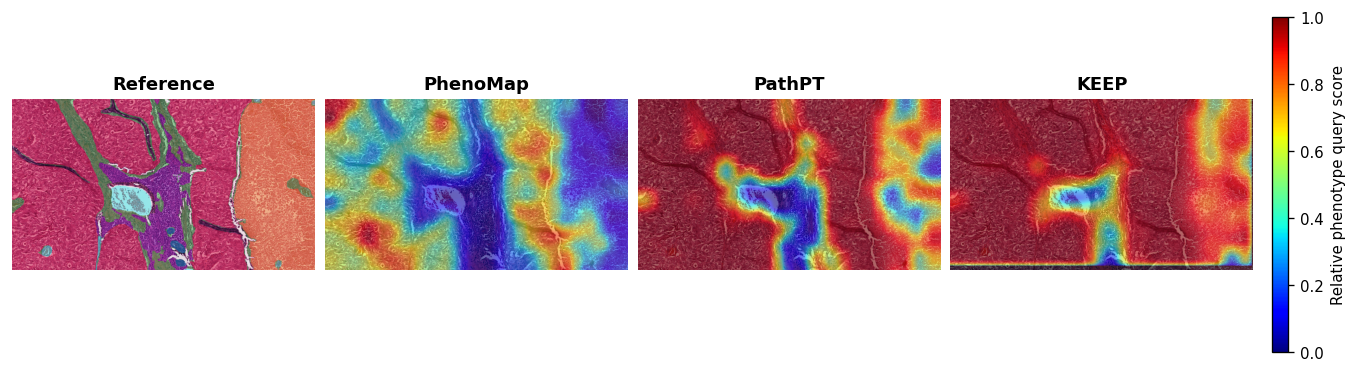

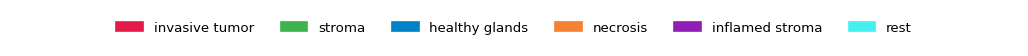

In [5]:
REPRESENTATIVE_EXTERNAL_ROI = (
    "tissue_bcss__TCGA-BH-A0RX-01Z-00-DX1.B4ABAFB9-6696-4F22-9468-DA56E1AD32D3_"
    "[34552, 11166, 37990, 13104]"
)
image = load_rgb(CROSS_IMAGES / f"{REPRESENTATIVE_EXTERNAL_ROI}.png")
mask = np.asarray(Image.open(CROSS_MASKS / f"{REPRESENTATIVE_EXTERNAL_ROI}.png"))
fig, axes = plt.subplots(1, 4, figsize=(11.2, 3.0), constrained_layout=True)
plot_mask_overlay(image, mask, TIGER_COLORS, ax=axes[0], title="Reference")
for ax, method in zip(axes[1:], METHODS):
    score = np.load(CROSS_SCORE_DIRS[method] / f"{REPRESENTATIVE_EXTERNAL_ROI}_score_map.npy")
    plot_query_score_map(score, ax=ax, title=method, background=image, cmap="jet")
for ax in axes:
    ax.axis("off")
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap="jet"),
    ax=axes[1:], fraction=0.025, pad=0.02,
)
colorbar.set_label("Relative phenotype query score")
plt.show()

legend_handles = [
    mpl.patches.Patch(color=TIGER_COLORS[value] / 255, label=label)
    for value, label in TIGER_LABELS.items() if value in np.unique(mask)
]
fig, ax = plt.subplots(figsize=(10.8, 0.35))
ax.legend(handles=legend_handles, loc="center", ncol=len(legend_handles), fontsize=8)
ax.axis("off")
plt.show()

The morphology-derived maps are displayed without label-guided post-processing. Their spatial agreement with the pathology overlay is therefore an evaluation result, not an inference input.

## 4. Evaluate HER2-IHC localization

The final protocol uses the 2,092 informative ROIs shared by all three methods, defined by a 10–90% proxy-positive fraction. The processed DAB proxy is resized bilinearly, a patch is positive at a proxy fraction of at least 0.20, and AUC, AP and best F1 are computed per ROI before cohort averaging.

HER2 ROI metric cache reused: True; common informative ROIs: 2,092


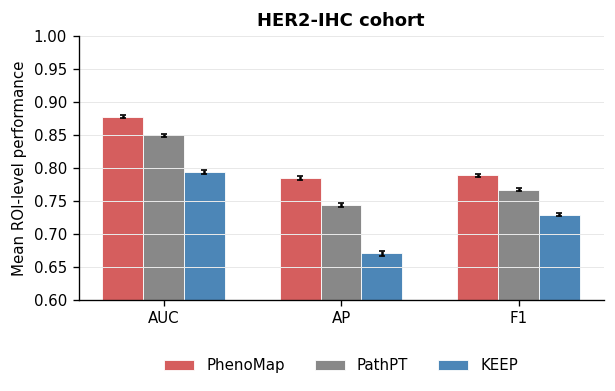

,AUC,AP,F1
Method,,,
PhenoMap,0.878,0.784,0.789
PathPT,0.850,0.743,0.767
KEEP,0.794,0.670,0.729


In [6]:
HER2_ROI_CACHE = tutorial_data.path("her2.evaluation_cache")

if HER2_ROI_CACHE.exists():
    her2_roi = pd.read_csv(HER2_ROI_CACHE)
    her2_metrics_cached = True
else:
    her2_roi = evaluate_proxy_rois(
        HER2_MASKS, HER2_SCORE_DIRS,
        positive_fraction_range=(0.10, 0.90), fractional_positive_threshold=0.20,
    )
    HER2_ROI_CACHE.parent.mkdir(parents=True, exist_ok=True)
    her2_roi.to_csv(HER2_ROI_CACHE, index=False)
    her2_metrics_cached = False

if "model" in her2_roi:
    her2_roi["method"] = her2_roi["model"].map(canonical_method_name)
her2_roi = her2_roi.loc[her2_roi["method"].isin(METHODS)].copy()
her2_summary = her2_roi.groupby("method")[["auc_roc", "auc_pr", "best_f1"]].agg(["mean", "sem"])
print(f"HER2 ROI metric cache reused: {her2_metrics_cached}; common informative ROIs: {her2_roi['stem'].nunique():,}")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
plot_method_metric_bars(
    her2_summary, METHODS, METHOD_COLORS, metric_specs, ax=ax, title="HER2-IHC cohort",
)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Mean ROI-level performance")
ax.grid(axis="y", color="#E8E8E8", linewidth=0.6)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3)
plt.tight_layout()
plt.show()

display(
    her2_summary.xs("mean", axis=1, level=1).loc[METHODS]
    .rename(columns={"auc_roc": "AUC", "auc_pr": "AP", "best_f1": "F1"})
    .round(3).rename_axis("Method")
)

PhenoMap remains strongest across all three ROI-level metrics in the independent HER2-IHC cohort. DAB-derived regions are used only as a post-inference spatial proxy.

## 5. Visualize HER2-associated queried regions

These four ROIs are the examples preserved in the final figure-producing asset. Each column aligns the processed DAB proxy with the H&E-only PhenoMap query over the identical field of view.

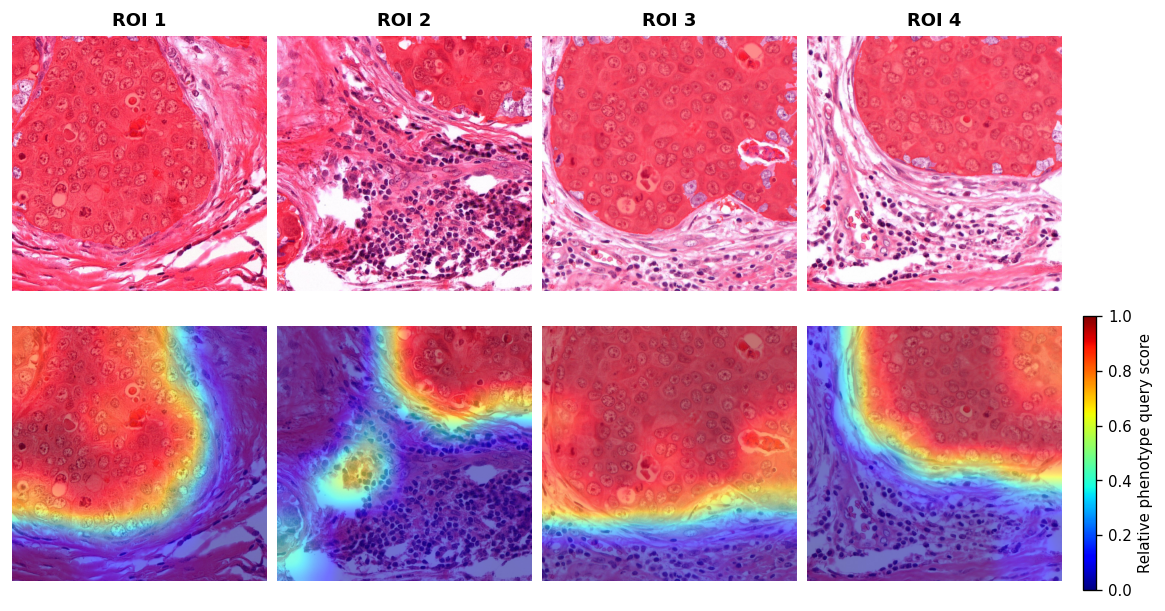

In [7]:
HER2_REPRESENTATIVE_ROIS = [
    "wsi010_id3761_x67584_y55296",
    "wsi010_id3617_x65536_y76800",
    "wsi010_id383_x21504_y86016",
    "wsi010_id210_x17408_y83968",
]
binary_colors = np.array([[0, 0, 0], [255, 0, 0]], dtype=np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(9.6, 5.0), constrained_layout=True)
for column, stem in enumerate(HER2_REPRESENTATIVE_ROIS):
    image = load_rgb(HER2_IMAGES / f"{stem}.png")
    mask = np.asarray(Image.open(HER2_MASKS / f"{stem}.png"))
    score = np.load(HER2_SCORE_DIRS["PhenoMap"] / f"{stem}_score_map.npy")
    plot_mask_overlay(image, mask, binary_colors, ax=axes[0, column], alpha=0.45)
    plot_query_score_map(score, ax=axes[1, column], background=image, cmap="jet")
    axes[0, column].set_title(f"ROI {column + 1}", fontweight="bold")
for ax in axes.ravel():
    ax.axis("off")
axes[0, 0].set_ylabel("DAB proxy", fontweight="bold")
axes[1, 0].set_ylabel("PhenoMap", fontweight="bold")
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap="jet"),
    ax=axes[1, :], fraction=0.025, pad=0.02,
)
colorbar.set_label("Relative phenotype query score")
plt.show()

## 6. Summary

The frozen HBC1 morphology query generalizes across pathology centers and an independent HER2-IHC cohort while outperforming KEEP and PathPT. All target annotations remain evaluation-only, and every large-scale prediction, DAB preprocessing and metric artifact is reused from cache.

In [8]:
expected_cross = {
    ("JB", "PhenoMap"): (0.901, 0.728, 0.722),
    ("JB", "PathPT"): (0.851, 0.619, 0.666),
    ("JB", "KEEP"): (0.831, 0.573, 0.659),
    ("RUMC", "PhenoMap"): (0.911, 0.790, 0.777),
    ("RUMC", "PathPT"): (0.885, 0.721, 0.761),
    ("RUMC", "KEEP"): (0.832, 0.645, 0.732),
    ("TCGA-BRCA", "PhenoMap"): (0.857, 0.772, 0.768),
    ("TCGA-BRCA", "PathPT"): (0.823, 0.732, 0.743),
    ("TCGA-BRCA", "KEEP"): (0.785, 0.681, 0.728),
}
for key, expected in expected_cross.items():
    observed = tuple(cross_summary.loc[key, (metric, "mean")] for metric, _ in metric_specs)
    assert np.allclose(observed, expected, atol=0.006), (key, observed)

expected_her2 = {
    "PhenoMap": (0.878, 0.784, 0.789),
    "PathPT": (0.850, 0.743, 0.767),
    "KEEP": (0.794, 0.670, 0.729),
}
for method, expected in expected_her2.items():
    observed = tuple(her2_summary.loc[method, (metric, "mean")] for metric, _ in metric_specs)
    assert np.allclose(observed, expected, atol=0.006), (method, observed)

assert cross_slide["logical_slide_id"].nunique() == 192
assert her2_roi["stem"].nunique() == 2092
assert all((HER2_IMAGES / f"{stem}.png").exists() for stem in HER2_REPRESENTATIVE_ROIS)
print("Tutorial checks passed: source-only caches, matching, aggregation and representative ROIs verified.")

Tutorial checks passed: source-only caches, matching, aggregation and representative ROIs verified.
